# GOOGL Stock Movement Prediction
## Part 6: iTransformer

The iTransformer (Liu et al., ICLR 2024) inverts the conventional
Transformer design for multivariate time series:

| Component | Standard Transformer | iTransformer |
|---|---|---|
| Token | one timestep (all variates) | one variate (all timesteps) |
| Attention | across time | across variates |
| FFN | maps temporal patterns | maps each variate's series |

This inversion is motivated by the observation that in high-dimensional
multivariate settings, naive temporal attention attends to semantically
unrelated time points across different variates simultaneously. By
treating each variate as a token, the model can learn which variables
are jointly informative while the FFN captures each variable's
temporal dynamics independently.

**Architecture used here:**
- Encoder length: 60 trading days (same as TFT for fair comparison)
- 2 iTransformer encoder layers
- d_model = 64 (variate embedding dimension)
- 4 attention heads
- FFN hidden = 256
- Dropout = 0.1
- Prediction head: linear projection from the CLS-like aggregated
  token representation to the scalar return target

**Same evaluation protocol as Parts 4 and 5:**
walk-forward split, non-overlapping rebalance simulation, identical metric functions.

In [1]:
!pip install torch pandas numpy scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 83.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 

In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler
 
warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)
 
PROCESSED_DIR = "data/processed"
MODEL_DIR     = "models"
os.makedirs(MODEL_DIR, exist_ok=True)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : Tesla T4


In [ ]:
df_raw = pd.read_csv(f"{PROCESSED_DIR}/features.csv", index_col=0, parse_dates=True)
 
with open(f"{PROCESSED_DIR}/split_index.json") as fh:
    split_index = json.load(fh)
 
with open(f"{PROCESSED_DIR}/selected_features.json") as fh:
    selected = json.load(fh)
 
SEQ_FEATURES = selected["sequence_model_features"]
TARGET_COLS  = selected["target_columns"]
HORIZONS     = {"target_return_1d": "1d", "target_return_5d": "5d", "target_return_20d": "20d"}
HORIZON_DAYS = {"1d": 1, "5d": 5, "20d": 20}
 
print(f"Dataset shape     : {df_raw.shape}")
print(f"Sequence features : {len(SEQ_FEATURES)}")

Dataset shape     : (3134, 157)
Sequence features : 89


## iTransformer Architecture

In [4]:
class InvertedMultiheadAttention(nn.Module):
    """
    Multi-head attention applied across the variate dimension.
    Input shape: (batch, n_variates, d_model)
    Each variate's embedding attends to all other variates' embeddings.
    """
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, n_variates, d_model)
        attn_out, _ = self.attn(x, x, x)
        return self.norm(x + self.drop(attn_out))
 
 
class VariateFeedForward(nn.Module):
    """
    Position-wise FFN applied independently to each variate's embedding.
    Captures temporal patterns within each variable.
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net  = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.norm(x + self.drop(self.net(x)))
 
 
class iTransformerLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.attn = InvertedMultiheadAttention(d_model, n_heads, dropout)
        self.ffn  = VariateFeedForward(d_model, d_ff, dropout)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.ffn(self.attn(x))
 
 
class iTransformer(nn.Module):
    """
    iTransformer for multivariate time series regression.
 
    Input:  (batch, seq_len, n_variates)   — sequence of feature vectors
    Output: (batch, 1)                     — scalar return prediction
 
    Each variate's time series (length seq_len) is projected to d_model
    to form the variate token. Attention is applied across the n_variates
    tokens. The output aggregates all variate representations via mean
    pooling before the prediction head.
    """
    def __init__(self, n_variates: int, seq_len: int,
                 d_model: int = 64, n_heads: int = 4,
                 d_ff: int = 256, n_layers: int = 2,
                 dropout: float = 0.1):
        super().__init__()
        # Project each variate's time series to d_model
        self.variate_embed = nn.Linear(seq_len, d_model)
 
        self.layers = nn.ModuleList([
            iTransformerLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
 
        self.norm = nn.LayerNorm(d_model)
        # Prediction head: mean-pooled representation -> scalar
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, n_variates)
        # Transpose to (batch, n_variates, seq_len) for variate-wise embedding
        x = x.permute(0, 2, 1)                      # (B, V, T)
        x = self.variate_embed(x)                    # (B, V, d_model)
 
        for layer in self.layers:
            x = layer(x)
 
        x = self.norm(x)
        x = x.mean(dim=1)                            # (B, d_model) — mean pool over variates
        return self.head(x).squeeze(-1)              # (B,)

In [5]:
class ReturnDataset(Dataset):
    """
    Sliding window dataset for return prediction.
    Each sample is a (seq_len, n_features) input window and a scalar target.
    """
    def __init__(self, features: np.ndarray, targets: np.ndarray, seq_len: int):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets  = torch.tensor(targets,  dtype=torch.float32)
        self.seq_len  = seq_len
 
    def __len__(self):
        return len(self.features) - self.seq_len
 
    def __getitem__(self, idx):
        x = self.features[idx : idx + self.seq_len]           # (seq_len, n_features)
        y = self.targets[idx + self.seq_len]                   # scalar
        return x, y

## Data Preparation

Features are scaled per-column using RobustScaler (median/IQR based), fitted only on the training split to prevent leakage. The scaler is applied identically to val and test splits before creating the datasets.

In [6]:
SEQ_LEN    = 60
BATCH_SIZE = 64

def prepare_splits(df: pd.DataFrame, feature_cols: list, target_col: str,
                   split_index: dict):
    """
    Returns scaled numpy arrays for train/val/test features and targets,
    plus the scaler (for potential inverse-transform later).
    """
    train_mask = (df.index >= split_index["train_start"]) & (df.index <= split_index["train_end"])
    val_mask   = (df.index >= split_index["val_start"])   & (df.index <= split_index["val_end"])
    test_mask  = (df.index >= split_index["test_start"])  & (df.index <= split_index["test_end"])
 
    # Fill NaN in features: ffill then bfill then 0
    feat_df = df[feature_cols].ffill().bfill().fillna(0.0)
 
    scaler = RobustScaler()
    X_train = scaler.fit_transform(feat_df[train_mask].values)
    X_val   = scaler.transform(feat_df[val_mask].values)
    X_test  = scaler.transform(feat_df[test_mask].values)
 
    y_train = df.loc[train_mask, target_col].fillna(0.0).values
    y_val   = df.loc[val_mask,   target_col].values   # keep NaN for evaluation masking
    y_test  = df.loc[test_mask,  target_col].values
 
    # Dates aligned to the prediction timestep (index of the target)
    val_dates  = df.index[val_mask]
    test_dates = df.index[test_mask]

    return X_train, X_val, X_test, y_train, y_val, y_test, val_dates, test_dates, scaler

## Training

In [7]:
ITRANS_HPARAMS = {
    "d_model"  : 64,
    "n_heads"  : 4,
    "d_ff"     : 256,
    "n_layers" : 2,
    "dropout"  : 0.1,
}
 
MAX_EPOCHS      = 60
PATIENCE        = 10
LEARNING_RATE   = 1e-3
WEIGHT_DECAY    = 1e-4
 
 
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
        # Skip batches where all targets are 0 (NaN-filled) — only in train
        optimizer.zero_grad()
        preds = model(x_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
    return total_loss / len(loader.dataset)
 
 
@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
        preds = model(x_batch)
        total_loss += criterion(preds, y_batch).item() * len(y_batch)
    return total_loss / len(loader.dataset)
 
 
@torch.no_grad()
def predict_all(model, features: np.ndarray, seq_len: int, batch_size: int = 128) -> np.ndarray:
    """Generate predictions for all valid windows in a feature array."""
    model.eval()
    preds = []
    n = len(features) - seq_len
    for start in range(0, n, batch_size):
        end   = min(start + batch_size, n)
        batch = torch.tensor(
            np.stack([features[i : i + seq_len] for i in range(start, end)]),
            dtype=torch.float32,
        ).to(DEVICE)
        preds.append(model(batch).cpu().numpy())
    return np.concatenate(preds)
 
 
def train_itransformer(X_train, X_val, y_train, y_val,
                       n_variates: int, horizon_label: str):
    """
    Trains one iTransformer. Returns the best model and training history.
    """
    # For training loader: fill target NaN with 0 (excluded via valid mask)
    y_train_clean = np.nan_to_num(y_train, nan=0.0)
    y_val_clean   = np.nan_to_num(y_val,   nan=0.0)
 
    train_ds = ReturnDataset(X_train, y_train_clean, SEQ_LEN)
    val_ds   = ReturnDataset(X_val,   y_val_clean,   SEQ_LEN)
 
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=2, pin_memory=True)
 
    model = iTransformer(
        n_variates=n_variates,
        seq_len=SEQ_LEN,
        **ITRANS_HPARAMS,
    ).to(DEVICE)
 
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable parameters: {n_params:,}")
 
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=1e-5)
    criterion = nn.HuberLoss(delta=0.01)
 
    best_val_loss = float("inf")
    best_state    = None
    patience_ctr  = 0
    history       = {"train": [], "val": []}
 
    for epoch in range(MAX_EPOCHS):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss   = eval_epoch(model,   val_loader,  criterion)
        scheduler.step()
 
        history["train"].append(train_loss)
        history["val"].append(val_loss)
 
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
 
        if patience_ctr >= PATIENCE:
            print(f"  Early stop at epoch {epoch + 1}")
            break
 
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | train={train_loss:.6f}  val={val_loss:.6f}")
 
    model.load_state_dict(best_state)
    path = f"{MODEL_DIR}/itransformer_{horizon_label}.pt"
    torch.save(best_state, path)
    print(f"  Best val loss: {best_val_loss:.6f}")
    print(f"  Model saved : {path}")
 
    return model, history

In [8]:
itransformer_models  = {}
itransformer_history = {}
itransformer_data    = {}
 
for target_col in TARGET_COLS:
    horizon = HORIZONS[target_col]
    print(f"\nTraining iTransformer for {horizon}...")
 
    (X_train, X_val, X_test, y_train, y_val, y_test,
     val_dates, test_dates, scaler) = prepare_splits(df_raw, SEQ_FEATURES, target_col, split_index)
 
    model, history = train_itransformer(
        X_train, X_val, y_train, y_val,
        n_variates=len(SEQ_FEATURES),
        horizon_label=horizon,
    )
 
    itransformer_models[horizon]  = model
    itransformer_history[horizon] = history
    itransformer_data[horizon]    = (X_val, X_test, y_val, y_test, val_dates, test_dates)
 
print("\nAll iTransformer models trained.")


Training iTransformer for 1d...
  Trainable parameters: 106,113
  Epoch  10 | train=0.000083  val=0.000132
  Epoch  20 | train=0.000075  val=0.000121
  Epoch  30 | train=0.000072  val=0.000124
  Early stop at epoch 32
  Best val loss: 0.000120
  Model saved : /kaggle/working/models/itransformer_1d.pt

Training iTransformer for 5d...
  Trainable parameters: 106,113
  Epoch  10 | train=0.000192  val=0.000471
  Early stop at epoch 11
  Best val loss: 0.000367
  Model saved : /kaggle/working/models/itransformer_5d.pt

Training iTransformer for 20d...
  Trainable parameters: 106,113
  Epoch  10 | train=0.000284  val=0.000810
  Early stop at epoch 11
  Best val loss: 0.000661
  Model saved : /kaggle/working/models/itransformer_20d.pt

All iTransformer models trained.


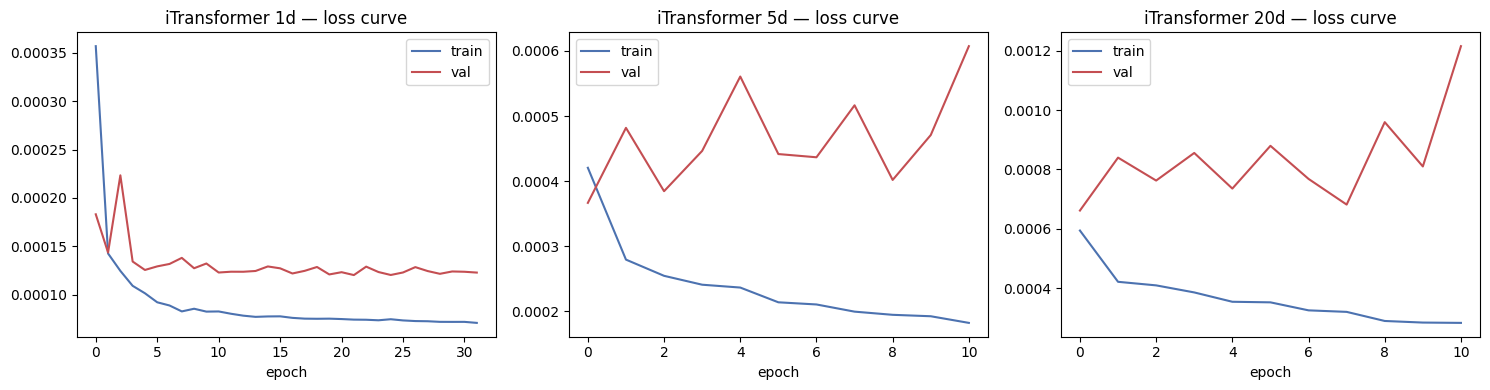

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, horizon in zip(axes, ["1d", "5d", "20d"]):
    h = itransformer_history[horizon]
    ax.plot(h["train"], label="train", color="#4C72B0")
    ax.plot(h["val"],   label="val",   color="#C44E52")
    ax.set_title(f"iTransformer {horizon} — loss curve")
    ax.set_xlabel("epoch")
    ax.legend()
plt.tight_layout()
plt.savefig("itransformer_loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## Generate Predictions and Evaluate

In [10]:
all_preds = {}
 
for target_col in TARGET_COLS:
    horizon = HORIZONS[target_col]
    model   = itransformer_models[horizon]
    X_val, X_test, y_val, y_test, val_dates, test_dates = itransformer_data[horizon]
 
    # Predictions start at index SEQ_LEN (first valid window)
    val_preds  = predict_all(model, X_val,  SEQ_LEN)
    test_preds = predict_all(model, X_test, SEQ_LEN)
 
    # Align predictions to the dates of their target timestep
    val_pred_dates  = val_dates[SEQ_LEN:]
    test_pred_dates = test_dates[SEQ_LEN:]
 
    val_actual  = y_val[SEQ_LEN:]
    test_actual = y_test[SEQ_LEN:]
 
    val_df = pd.DataFrame({
        "pred": val_preds, "actual": val_actual, "split": "val"
    }, index=val_pred_dates)
 
    test_df = pd.DataFrame({
        "pred": test_preds, "actual": test_actual, "split": "test"
    }, index=test_pred_dates)
 
    combined = pd.concat([val_df, test_df])
    combined.loc[combined["actual"] == 0, "actual"] = np.nan   # restore NaN
    all_preds[horizon] = combined
    print(f"{horizon}: val={len(val_df)}  test={len(test_df)}  valid targets={combined['actual'].notna().sum()}")

1d: val=441  test=558  valid targets=996
5d: val=441  test=558  valid targets=993
20d: val=441  test=558  valid targets=979


In [11]:
TRANSACTION_COST_BPS  = 5
TRADING_DAYS_PER_YEAR = 252

def compute_regression_metrics(actual, predicted):
    valid = actual.notna() & predicted.notna()
    a, p  = actual[valid], predicted[valid]
    return {
        "mae": float(mean_absolute_error(a, p)),
        "rmse": float(np.sqrt(mean_squared_error(a, p))),
        "r2": float(r2_score(a, p)),
        "n": int(valid.sum()),
    }

def compute_directional_accuracy(actual, predicted):
    valid = actual.notna() & predicted.notna()
    a, p  = actual[valid], predicted[valid]
    return {
        "accuracy" : float((np.sign(a) == np.sign(p)).mean()),
        "base_rate": float((a > 0).mean()),
        "n"        : int(valid.sum()),
    }

def simulate_strategy(actual_returns, predicted_returns, horizon_days, threshold=0.0):
    valid = actual_returns.notna() & predicted_returns.notna()
    a, p  = actual_returns[valid], predicted_returns[valid]
    block_idx    = a.index[::horizon_days]
    a_block, p_block = a.loc[block_idx], p.loc[block_idx]
    position     = (p_block > threshold).astype(int)
    pos_change   = position.diff().abs().fillna(position.iloc[0] if len(position) > 0 else 0)
    net_ret      = position * a_block - pos_change * (TRANSACTION_COST_BPS / 10000)
    bh_ret       = a_block
    ppy          = TRADING_DAYS_PER_YEAR / horizon_days
    sharpe       = float(net_ret.mean() / net_ret.std() * np.sqrt(ppy)) if net_ret.std() > 0 else 0.0
    bh_sharpe    = float(bh_ret.mean() / bh_ret.std() * np.sqrt(ppy)) if bh_ret.std() > 0 else 0.0
    cum_strat    = (1 + net_ret).cumprod()
    cum_bh       = (1 + bh_ret).cumprod()
    return {
        "sharpe_ratio"       : sharpe,
        "buy_hold_sharpe"    : bh_sharpe,
        "total_return"       : float(cum_strat.iloc[-1] - 1) if len(cum_strat) > 0 else 0.0,
        "buy_hold_return"    : float(cum_bh.iloc[-1] - 1) if len(cum_bh) > 0 else 0.0,
        "n_trades"           : int(pos_change.sum()),
        "n_periods"          : int(len(net_ret)),
        "cumulative_strategy": cum_strat,
        "cumulative_bh"      : cum_bh,
    }

regression_results  = {}
directional_results = {}
strategy_results    = {}
 
for target_col in TARGET_COLS:
    horizon = HORIZONS[target_col]
    preds   = all_preds[horizon]
 
    val_mask  = preds["split"] == "val"
    test_mask = preds["split"] == "test"
 
    regression_results[horizon]  = {}
    directional_results[horizon] = {}
    strategy_results[horizon]    = {}
 
    for split_name, mask in [("val", val_mask), ("test", test_mask)]:
        actual    = preds.loc[mask, "actual"]
        predicted = preds.loc[mask, "pred"]
 
        regression_results[horizon][split_name]  = compute_regression_metrics(actual, predicted)
        directional_results[horizon][split_name] = compute_directional_accuracy(actual, predicted)
        strategy_results[horizon][split_name]    = simulate_strategy(
            actual, predicted, HORIZON_DAYS[horizon]
        )
 
print("Regression metrics:")
for h in ["1d", "5d", "20d"]:
    print(f"\n  {h}:")
    for s in ["val", "test"]:
        m = regression_results[h][s]
        print(f"    {s:<5} | MAE={m['mae']:.5f}  RMSE={m['rmse']:.5f}  R2={m['r2']:+.4f}  n={m['n']}")
 
print("\nDirectional accuracy:")
print(f"{'Horizon':<8}{'Split':<6}{'Accuracy':<12}{'Base Rate':<12}{'Edge':<10}")
for h in ["1d", "5d", "20d"]:
    for s in ["val", "test"]:
        r    = directional_results[h][s]
        edge = r["accuracy"] - max(r["base_rate"], 1 - r["base_rate"])
        print(f"{h:<8}{s:<6}{r['accuracy']:<12.4f}{r['base_rate']:<12.4f}{edge:>+8.4f}")
 
print("\nStrategy (non-overlapping rebalance):")
print(f"{'Horizon':<8}{'Split':<6}{'Sharpe':<10}{'B&H Sharpe':<12}{'Return':<12}{'B&H Return':<12}{'Periods'}")
for h in ["1d", "5d", "20d"]:
    for s in ["val", "test"]:
        r = strategy_results[h][s]
        print(f"{h:<8}{s:<6}{r['sharpe_ratio']:<10.3f}{r['buy_hold_sharpe']:<12.3f}"
              f"{r['total_return']:<+12.3f}{r['buy_hold_return']:<+12.3f}{r['n_periods']}")

Regression metrics:

  1d:
    val   | MAE=0.01635  RMSE=0.02199  R2=-0.0075  n=440
    test  | MAE=0.01419  RMSE=0.01964  R2=-0.0415  n=556

  5d:
    val   | MAE=0.04122  RMSE=0.05186  R2=-0.2128  n=440
    test  | MAE=0.04380  RMSE=0.05642  R2=-0.7455  n=553

  20d:
    val   | MAE=0.07092  RMSE=0.08878  R2=-0.1813  n=441
    test  | MAE=0.07365  RMSE=0.09330  R2=-0.0460  n=538

Directional accuracy:
Horizon Split Accuracy    Base Rate   Edge      
1d      val   0.5045      0.4955       +0.0000
1d      test  0.5144      0.5468       -0.0324
5d      val   0.5386      0.5091       +0.0295
5d      test  0.5588      0.5823       -0.0235
20d     val   0.5374      0.5488       -0.0113
20d     test  0.6264      0.6487       -0.0223

Strategy (non-overlapping rebalance):
Horizon Split Sharpe    B&H Sharpe  Return      B&H Return  Periods
1d      val   -0.459    0.130       -0.265      -0.027      440
1d      test  1.091     1.486       +0.595      +1.460      556
5d      val   0.361     0.1

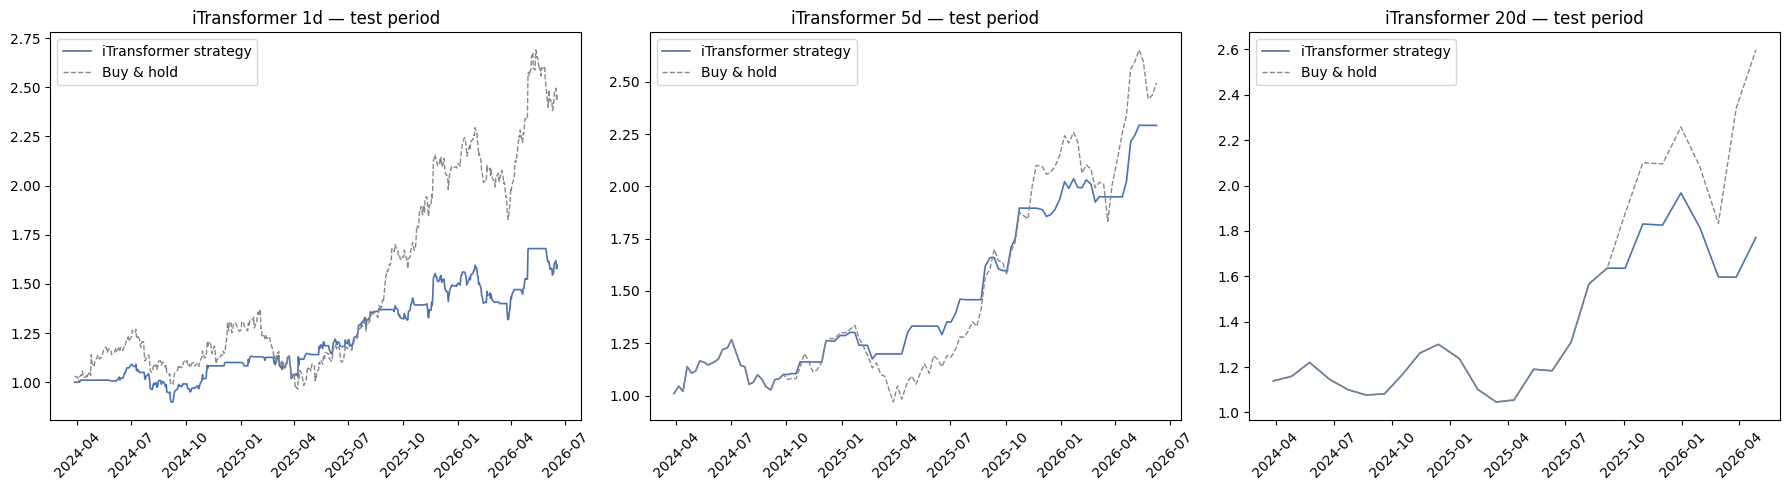

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, horizon in zip(axes, ["1d", "5d", "20d"]):
    r = strategy_results[horizon]["test"]
    ax.plot(r["cumulative_strategy"].index, r["cumulative_strategy"],
            label="iTransformer strategy", color="#4C72B0", linewidth=1.2)
    ax.plot(r["cumulative_bh"].index, r["cumulative_bh"],
            label="Buy & hold", color="#888888", linewidth=1.0, linestyle="--")
    ax.set_title(f"iTransformer {horizon} — test period")
    ax.legend()
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("itransformer_strategy_performance.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
pred_combined = {}
for target_col in TARGET_COLS:
    horizon = HORIZONS[target_col]
    preds   = all_preds[horizon]
    pred_combined[f"pred_{horizon}"]   = preds["pred"]
    pred_combined[f"actual_{horizon}"] = preds["actual"]
pd.DataFrame(pred_combined).to_csv(f"{PROCESSED_DIR}/itransformer_predictions.csv")
 
itrans_metrics = {
    "regression" : regression_results,
    "directional": directional_results,
    "strategy"   : {
        h: {s: {k: v for k, v in r.items() if not isinstance(v, (pd.Series, np.ndarray))}
            for s, r in splits.items()}
        for h, splits in strategy_results.items()
    },
}
with open(f"{PROCESSED_DIR}/itransformer_metrics.json", "w") as fh:
    json.dump(itrans_metrics, fh, indent=2)

print("  PART 6 SUMMARY — iTransformer")
for horizon in ["1d", "5d", "20d"]:
    r_reg = regression_results[horizon]["test"]
    r_dir = directional_results[horizon]["test"]
    r_str = strategy_results[horizon]["test"]
    print(f"\n  {horizon} horizon (test set):")
    print(f"    MAE              : {r_reg['mae']:.5f}")
    print(f"    Directional acc  : {r_dir['accuracy']:.4f}  (base rate: {r_dir['base_rate']:.4f})")
    print(f"    Strategy Sharpe  : {r_str['sharpe_ratio']:.3f}  (buy-hold: {r_str['buy_hold_sharpe']:.3f})")
    print(f"    Strategy return  : {r_str['total_return']:+.3f}  (buy-hold: {r_str['buy_hold_return']:+.3f})")

print(f"  Predictions : {PROCESSED_DIR}/itransformer_predictions.csv")
print(f"  Metrics     : {PROCESSED_DIR}/itransformer_metrics.json")
print("\n  Ready for Part 7: Evaluation & Comparison")

  PART 6 SUMMARY — iTransformer

  1d horizon (test set):
    MAE              : 0.01419
    Directional acc  : 0.5144  (base rate: 0.5468)
    Strategy Sharpe  : 1.091  (buy-hold: 1.486)
    Strategy return  : +0.595  (buy-hold: +1.460)

  5d horizon (test set):
    MAE              : 0.04380
    Directional acc  : 0.5588  (base rate: 0.5823)
    Strategy Sharpe  : 1.832  (buy-hold: 1.529)
    Strategy return  : +1.291  (buy-hold: +1.495)

  20d horizon (test set):
    MAE              : 0.07365
    Directional acc  : 0.6264  (base rate: 0.6487)
    Strategy Sharpe  : 1.089  (buy-hold: 1.498)
    Strategy return  : +0.771  (buy-hold: +1.598)

  Predictions : /kaggle/working/output/itransformer_predictions.csv
  Metrics     : /kaggle/working/output/itransformer_metrics.json

  Ready for Part 7: Evaluation & Comparison
